# Partial Search Graph Materialisation

In this study we consider the operation of materialising successors in the search graph of selectable conjunction extents. Each node in this graph can be idenfied with

1. a selectable extent $I' \subseteq I = \{1,\dots, n\}$, i.e., there is at least one conjunctive query $q \in \mathcal Q$ such that $I_q=I'$,
2. a unique closure $Q=\{p \in \mathcal P \, : \, I' \subseteq I_p\}$ corresponding to the most specific conjunction that selects $I'$,
3. a unique canonical key, which is the lexicographically minimal $q$ such that $I_{q}=I'$

The third characterisation depends on some arbitrary but fixed order $\mathcal P =\{p_1, \dots, p_k\}$ This allows us to identify conjunctions with the index set of propositions contained in them, i.e.,
$$
q \sqsubseteq q' \equiv q=q' \text{ or } \min q \Delta q' \in q \enspace .
$$

Two such nodes representing distinct extensions $I_q' \subset I_q$ are naturally connected by a directed edge if there is a single proposition $p$ such that $I_{q'} = I_{qp}$. This edge relation is natural in the sense that out-edges can be easily and efficiently enumerated if one has access to the closure $C$ of a node or its complement, because every $p \not\in C$ corresponds to an out-edge of the search graph.

However, to enable an efficient node search one has to avoid exploring node subsets multiple times. The two main approaches to do this are:

1. Explicitly maintaining the set of already visited nodes, typically in a hash set
2. Use only a subset of canonical edges that induces a spanning tree of the full search graph and that can be locally filtered out of the set of all candidate out-edges of a node

The main challenge for the first approach is to define computationally efficient hash values. When working with a propositionalisation of $d$ numeric variables, it is possible to work with $O(d)$ keys representing the closure. We might explore this option at a later stage, mainly because of difficulties implementing it with numba.

## Canonical Edges

An edge $(q, qp)$ is called canonical if both $q$ and $qp$ are canonical keys. The canonical edges induce a spanning tree of the search graph, hence, they are an attractive choice for performing an efficient search within the graph that avoids exploring node subsets multiple times. 

Unfortunately, the canonical out-edges from a given node are not given explicitly. The standard strategy is to test each edge given by a $p \in \mathcal P \setminus C(q) \cap \{\max q,\dots, k\}$ for canonicity.

In [1]:
import numpy as np

RNG = np.random.default_rng(seed=0)
x = RNG.multivariate_normal([0, 0, 0], [[1, 0.5, -0.5],[0.5, 1, -0.5], [-0.5, -0.5, 1]], size=100)
x

array([[ 2.67089894e-01, -3.53584822e-01,  2.21479959e-01],
       [ 1.23116415e-01, -4.57868775e-01, -7.78005984e-02],
       [-1.47101331e+00, -3.88020233e-01,  1.33510120e+00],
       [ 1.05707187e+00,  7.09645291e-01, -1.33291975e+00],
       [ 1.17905266e+00,  2.14864736e+00, -2.36743902e+00],
       [ 4.15277811e-01,  4.17072290e-01, -9.61331273e-01],
       [-4.10304448e-01,  2.22266520e-01,  8.20246849e-01],
       [-9.12768318e-01, -1.54978231e+00,  8.84587632e-01],
       [-1.16693981e+00, -4.76044420e-01,  5.70056717e-01],
       [ 8.79715332e-01,  4.60157849e-01, -9.17883674e-01],
       [ 7.32421193e-01,  7.65726309e-01, -9.74901884e-01],
       [-2.36424041e-01, -4.36856274e-01,  6.51515397e-01],
       [ 9.86477273e-01,  2.42727783e-01, -3.72341417e-01],
       [-3.45317125e-01, -2.28594634e+00,  1.02688081e+00],
       [-9.46219153e-01, -7.84588746e-01,  1.56590015e+00],
       [ 1.38807257e+00,  4.19449413e-01,  1.03857127e+00],
       [-1.26469504e+00, -9.16643667e-01

In [35]:
from numba.types import int64, float64
from numba.experimental import jitclass

@jitclass
class Propositionalization:

    v: int64[:]
    t: float64[:]
    s: int64[:]

    def __init__(self, v, t, s):
        self.v = v
        self.t = t
        self.s = s

    def support(self, p, x):
        return np.flatnonzero(self.s[p]*x[:,self.v[p]] >= self.t[p])
    
    def binarize(self, x):
        return self.s*x[:, self.v] >= self.t
    
    def implied(self, p, x, l=None, u=None):
        l = np.min(x[:, self.v[p]])
        u = np.max(x[:, self.v[p]])
        if self.s[p]==1:
            return l >= self.t[p]
        else:
            return -u >= self.t[p]
        
    # def critical(self, q, x):
    #     j = 0
    #     for p in q:
    #         while j < p:
    #             if self.implied(j, x):
    #                 return j
    #             j = j + 1
    #         j = j + 1
    #     return -1

def to_string(prop, j):
    return f'x{prop.v[j]+1} {'>=' if prop.s[j]==1 else '<='} {prop.s[j]*prop.t[j]:0.3f}'

def tautologies_vectorized(prop, x, rem=None):
    rem = rem if rem is not None else np.arange(len(prop.v))
    l=np.min(x, axis=0)
    u=np.max(x, axis=0)

    res = np.zeros(len(prop.v[rem]), dtype=bool)
    np.greater_equal(l[prop.v[rem]], prop.t[rem], where=prop.s[rem]==1, out=res)
    np.greater_equal(-u[prop.v[rem]], prop.t[rem], where=prop.s[rem]==-1, out=res)

    return np.flatnonzero(res)

def extent_vectorized(prop, q, x):
    q = np.atleast_1d(q)
    return np.flatnonzero(np.prod(prop.s[q]*x[:, prop.v[q]] >= prop.t[q], axis=1, dtype=bool))

def make_propositionalization(x):
    n, p = x.shape
    v = np.repeat(np.arange(p), n)
    t = x.T.flatten()
    s = np.repeat([1, -1], p*n)
    return Propositionalization(np.concatenate((v, v)), np.concatenate((t, -t)), s)

prop = make_propositionalization(x)

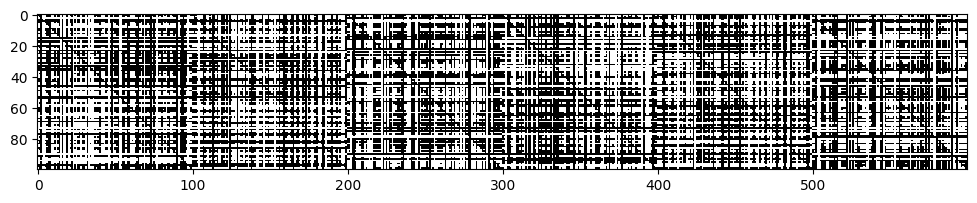

In [ ]:
from matplotlib import pyplot as plt

binary = prop.binarize(x)
plt.figure(figsize=(12, 20))
plt.imshow(binary, cmap='Greys', interpolation='none')
plt.show()

In [26]:
root_key = np.array([], dtype=np.int64)
root_sup = extent_vectorized(prop, root_key, x)
root_closure = tautologies_vectorized(prop, x[root_sup])
root_closure

array([ 73, 113, 279, 323, 446, 590])

In [34]:
from numba.types import int64
from numba.experimental import jitclass

@jitclass
class Node:

    key: int64[:]
    closure: int64[:]
    support: int64[:]

    def __init__(self, key, closure, support):
        self.key = key
        self.closure = closure
        self.support = support

def node_to_string(node):
    return f'Node({node.key})'

root = Node(root_key, root_closure, root_sup)
node_to_string(root)

'Node([])'

In [36]:
np.append(np.array([1, 2, 3]), 4)

array([1, 2, 3, 4])

In [ ]:
def simple_refinement_vectorised(node, p, prop, x):
    _key = np.append(node.key, p)
    _sup = prop.support(p, x[node.support])
    _closure = tautologies_vectorized(prop, x[_sup])
    return Node(_key, _closure, _sup)

def inefficient_canonicity_check(node, refinement):
    return np.setdiff1d(refinement.closure, node.closure)[0]==refinement.key[-1]
    # critical index = node.closure 

refs = simple_refinement_vectorised(root, 10, prop, x)
inefficient_canonicity_check(root, ref)

np.False_

In [50]:
%timeit simple_refinement_vectorised(root, 10, prop, x)

22.6 μs ± 244 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
